In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [68]:
# Загрузка данных
df = pd.read_csv('skab_valve_1.csv', delimiter=';')

# Чтение данных
import io
print("Размер данных:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

# Преобразование datetime
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')

print("\nИнформация о данных:")
print(df.info())

Размер данных: (1094, 11)

Первые 5 строк:
              datetime  Accelerometer1RMS  Accelerometer2RMS  Current  \
0  2020-03-09 12:34:37           0.028030           0.040400  1.18285   
1  2020-03-09 12:34:38           0.026952           0.038880  1.45268   
2  2020-03-09 12:34:39           0.027958           0.040660  1.02300   
3  2020-03-09 12:34:40           0.027277           0.040736  1.22751   
4  2020-03-09 12:34:41           0.027210           0.039489  1.21526   

   Pressure  Temperature  Thermocouple  Voltage  Volume Flow RateRMS  anomaly  \
0  0.054711      69.9219       24.9122  229.918              32.9875      0.0   
1 -0.273216      69.9147       24.9038  219.566              32.0129      0.0   
2  0.054711      69.8861       24.9055  237.717              32.9875      0.0   
3 -0.273216      69.8397       24.9110  227.621              32.0000      0.0   
4 -0.273216      69.9136       24.9110  221.634              32.0129      0.0   

   changepoint  
0          0.0

Базовый анализ данных

In [69]:
# Проверка распределения аномалий
print("Распределение аномалий:")
print(df['anomaly'].value_counts())
print(f"Процент аномалий: {df['anomaly'].mean()*100:.2f}%")

Распределение аномалий:
anomaly
0.0    689
1.0    405
Name: count, dtype: int64
Процент аномалий: 37.02%


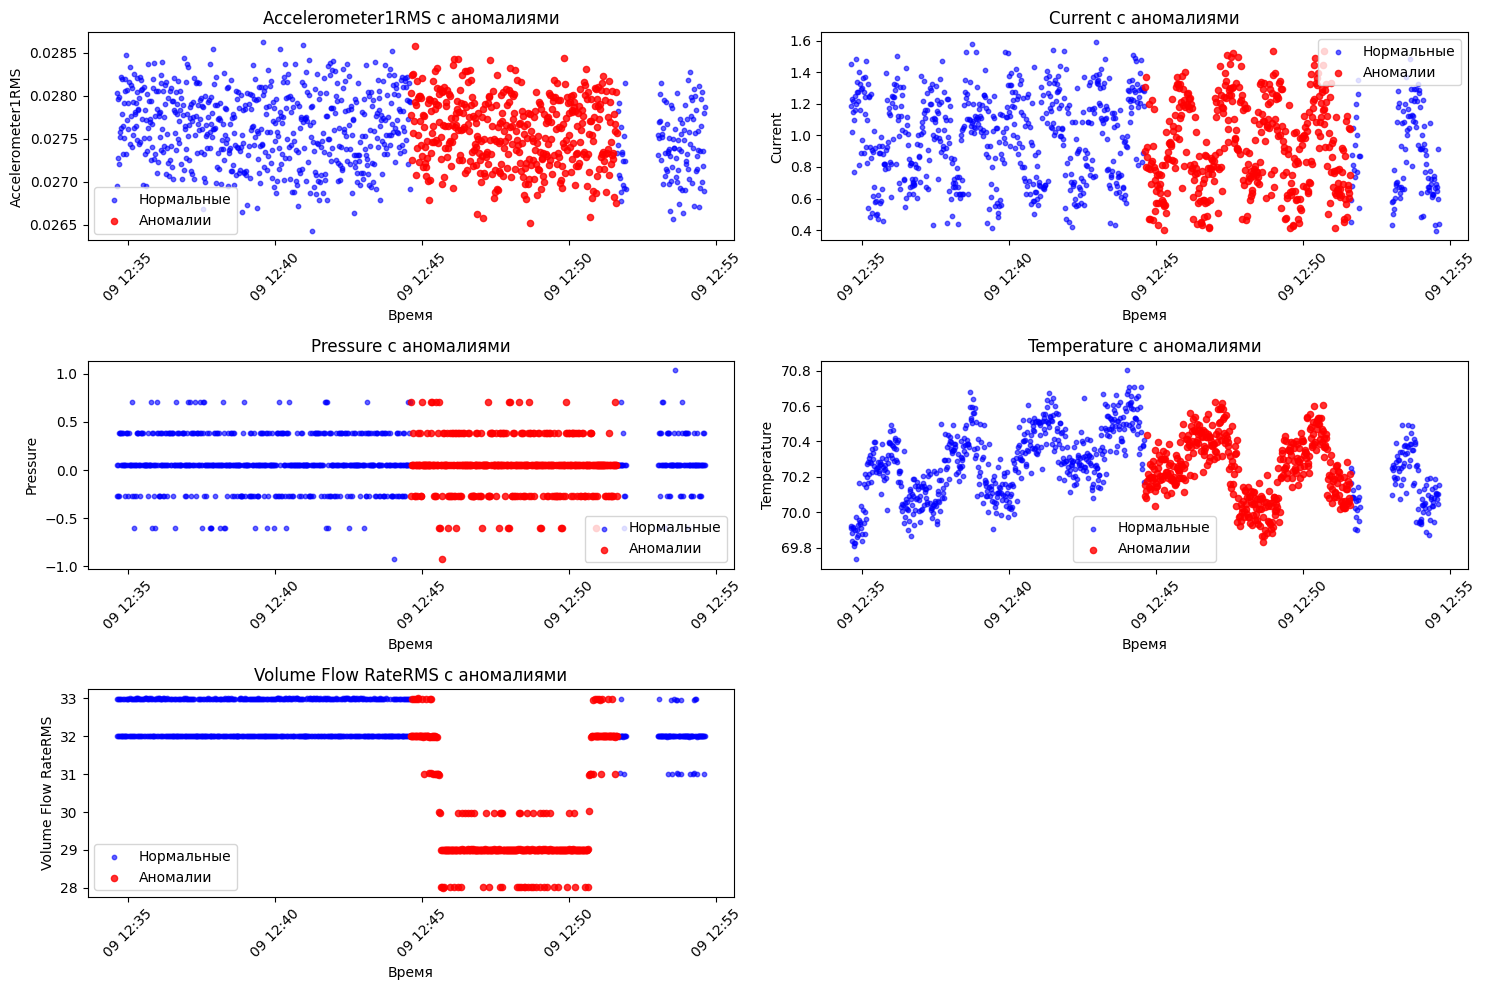

In [70]:
# Визуализация временных рядов с аномалиями
plt.figure(figsize=(15, 10))

# Выберем несколько ключевых параметров для визуализации
features_to_plot = ['Accelerometer1RMS', 'Current', 'Pressure', 'Temperature', 'Volume Flow RateRMS']

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(3, 2, i)

    # Нормальные точки
    normal_data = df[df['anomaly'] == 0]
    plt.scatter(normal_data.index, normal_data[feature],
                alpha=0.6, s=10, label='Нормальные', color='blue')

    # Аномальные точки
    anomaly_data = df[df['anomaly'] == 1]
    plt.scatter(anomaly_data.index, anomaly_data[feature],
                alpha=0.8, s=20, label='Аномалии', color='red')

    plt.title(f'{feature} с аномалиями')
    plt.xlabel('Время')
    plt.ylabel(feature)
    plt.legend()
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Фильтрация на основе статистик (IQR)

In [74]:
def detect_anomalies_iqr(data, features, multiplier=1.5):
    """
    Обнаружение аномалий с помощью IQR
    """
    anomalies = pd.Series([0] * len(data), index=data.index)

    for feature in features:
        Q1 = data[feature].quantile(0.25)
        Q3 = data[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR

        # Отмечаем аномалии
        feature_anomalies = (data[feature] < lower_bound) | (data[feature] > upper_bound)
        anomalies[feature_anomalies] = 1

    return anomalies

In [75]:
# Выбираем числовые признаки (исключаем метки)
numerical_features = [col for col in df.columns if col not in ['anomaly', 'changepoint']]

print("Числовые признаки для анализа:", numerical_features)

# Применяем IQR с разными множителями
anomalies_iqr_1_5 = detect_anomalies_iqr(df, numerical_features, multiplier=1.5)
anomalies_iqr_3 = detect_anomalies_iqr(df, numerical_features, multiplier=3)

print(f"Аномалий с IQR 1.5: {anomalies_iqr_1_5.sum()} ({anomalies_iqr_1_5.mean()*100:.2f}%)")
print(f"Аномалий с IQR 3: {anomalies_iqr_3.sum()} ({anomalies_iqr_3.mean()*100:.2f}%)")

Числовые признаки для анализа: ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']
Аномалий с IQR 1.5: 105 (9.60%)
Аномалий с IQR 3: 2 (0.18%)


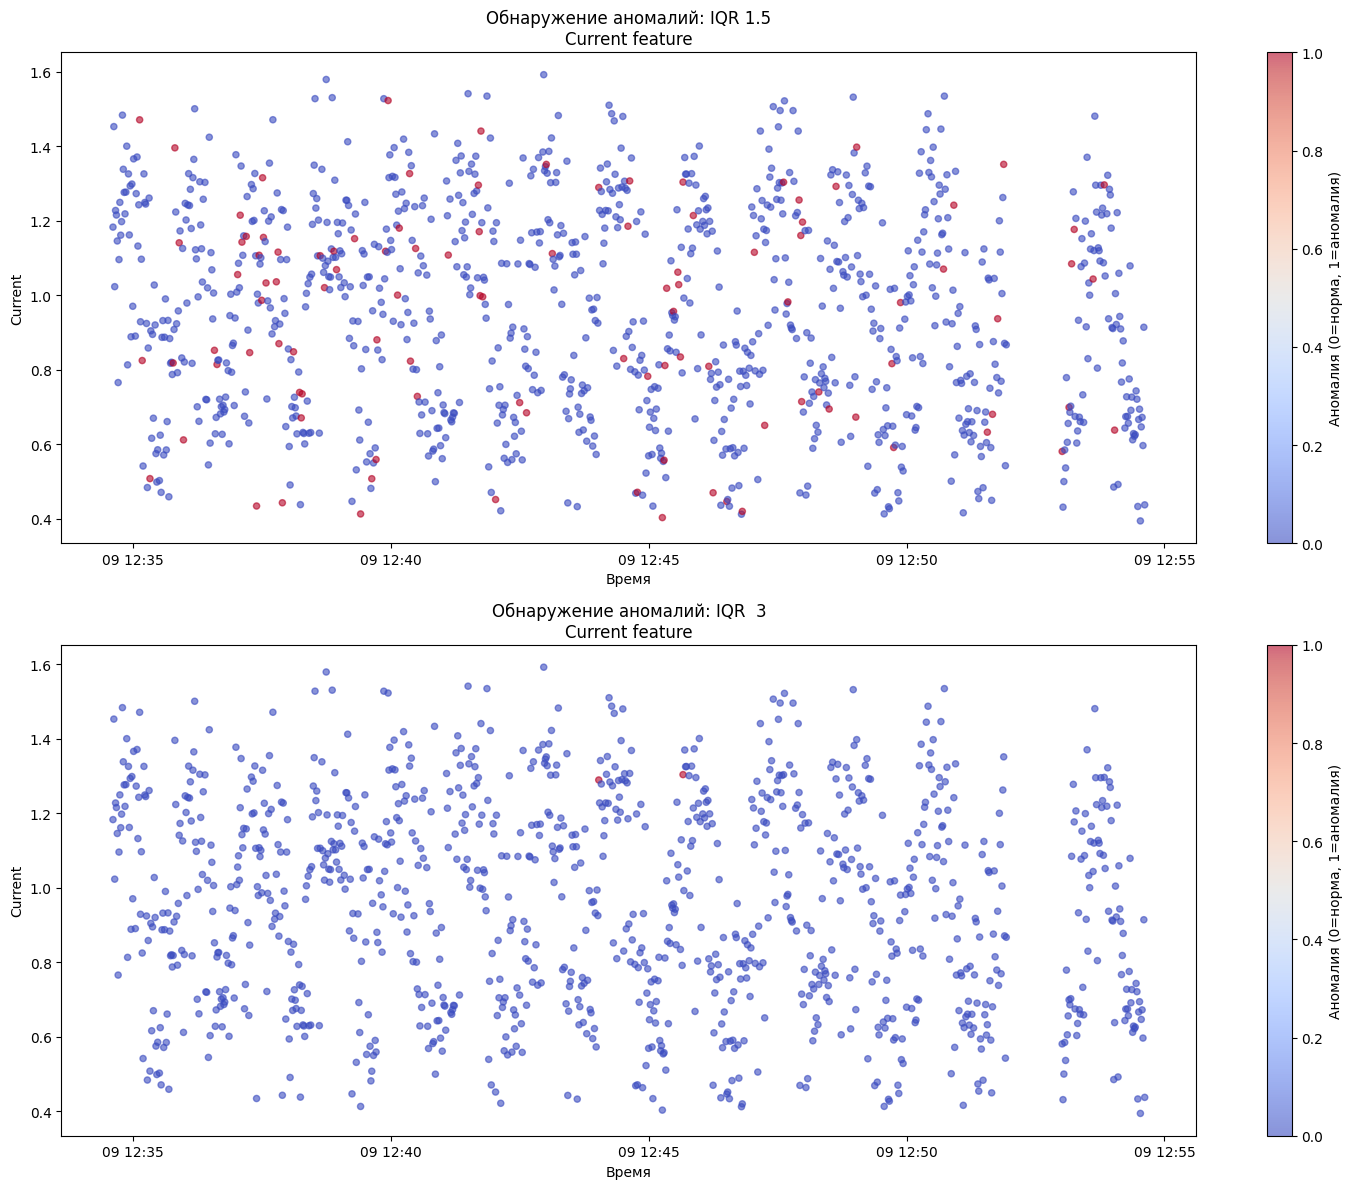

In [76]:
# Визуализация результатов IQR
plt.figure(figsize=(15, 12))

# IQR 1.5
plt.subplot(2, 1, 1)
plt.scatter(df.index, df['Current'],
           c=anomalies_iqr_1_5, cmap='coolwarm', alpha=0.6, s=20)
plt.title('Обнаружение аномалий: IQR 1.5\nCurrent feature')
plt.xlabel('Время')
plt.ylabel('Current')
plt.colorbar(label='Аномалия (0=норма, 1=аномалия)')

# IQR 3
plt.subplot(2, 1, 2)
plt.scatter(df.index, df['Current'],
           c=anomalies_iqr_3, cmap='coolwarm', alpha=0.6, s=20)
plt.title('Обнаружение аномалий: IQR  3\nCurrent feature')
plt.xlabel('Время')
plt.ylabel('Current')
plt.colorbar(label='Аномалия (0=норма, 1=аномалия)')

plt.tight_layout()
plt.show()

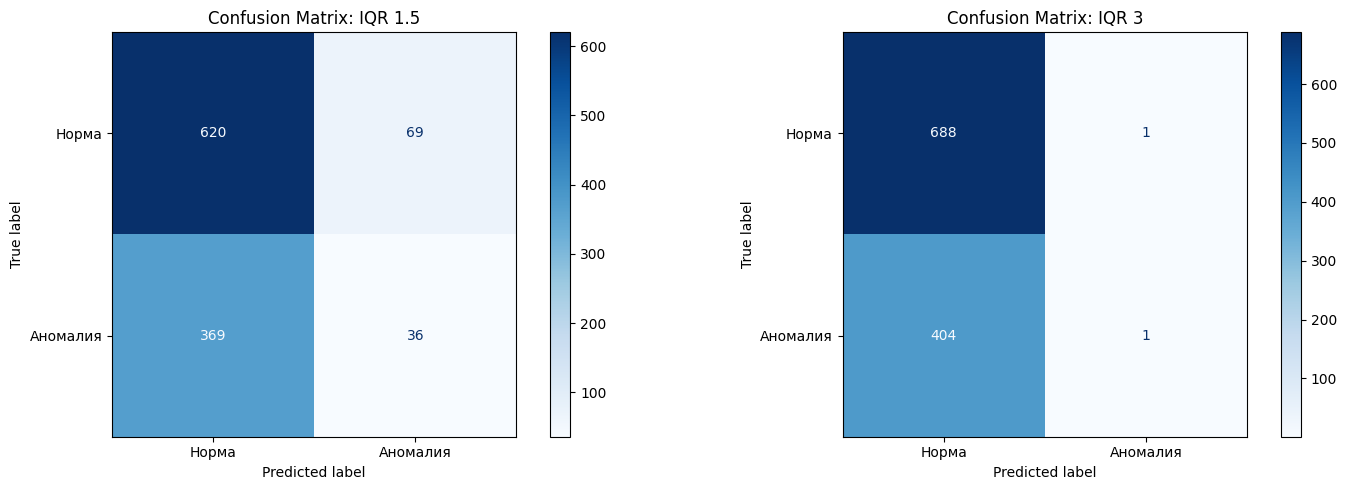

IQR 1.5:
              precision    recall  f1-score   support

         0.0       0.63      0.90      0.74       689
         1.0       0.34      0.09      0.14       405

    accuracy                           0.60      1094
   macro avg       0.48      0.49      0.44      1094
weighted avg       0.52      0.60      0.52      1094


IQR 3:
              precision    recall  f1-score   support

         0.0       0.63      1.00      0.77       689
         1.0       0.50      0.00      0.00       405

    accuracy                           0.63      1094
   macro avg       0.57      0.50      0.39      1094
weighted avg       0.58      0.63      0.49      1094



In [112]:
# Матрицы ошибок для IQR
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Для IQR 1.5
cm_iqr_1_5 = confusion_matrix(df['anomaly'], anomalies_iqr_1_5)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_iqr_1_5,
                              display_labels=['Норма', 'Аномалия'])
disp1.plot(ax=ax1, cmap='Blues')
ax1.set_title('Confusion Matrix: IQR 1.5')

# Для IQR 3
cm_iqr_3 = confusion_matrix(df['anomaly'], anomalies_iqr_3)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_iqr_3,
                              display_labels=['Норма', 'Аномалия'])
disp2.plot(ax=ax2, cmap='Blues')
ax2.set_title('Confusion Matrix: IQR 3')

plt.tight_layout()
plt.show()

print("IQR 1.5:")
print(classification_report(df['anomaly'], anomalies_iqr_1_5))

print("\nIQR 3:")
print(classification_report(df['anomaly'], anomalies_iqr_3))

In [111]:
results = {}
results['IQR_1.5'] = classification_report(df['anomaly'], anomalies_iqr_1_5,)
results['IQR_3.0'] = classification_report(df['anomaly'], anomalies_iqr_3,)

Кластеризация с Feature Engineering

In [113]:
def create_features(data, window_size=5):
    """
    Создание дополнительных признаков для временных рядов
    """
    features_df = data[numerical_features].copy()

    # Лаги (запаздывающие значения)
    for feature in numerical_features:
        for lag in [1, 2, 3]:
            features_df[f'{feature}_lag_{lag}'] = data[feature].shift(lag)

    # Скользящие статистики
    for feature in numerical_features[:6]:  # Берем первые 6 признаков чтобы не перегружать
        features_df[f'{feature}_rolling_mean_{window_size}'] = data[feature].rolling(window=window_size).mean()
        features_df[f'{feature}_rolling_std_{window_size}'] = data[feature].rolling(window=window_size).std()
        features_df[f'{feature}_rolling_min_{window_size}'] = data[feature].rolling(window=window_size).min()
        features_df[f'{feature}_rolling_max_{window_size}'] = data[feature].rolling(window=window_size).max()

    # Признаки времени
    features_df['hour'] = data.index.hour
    features_df['minute'] = data.index.minute
    features_df['second'] = data.index.second

    # Разности (производные)
    for feature in numerical_features[:4]:
        features_df[f'{feature}_diff_1'] = data[feature].diff(1)

    # Удаляем строки с NaN (из-за лагов и скользящих окон)
    features_df = features_df.dropna()

    return features_df

In [114]:
# Создаем расширенные признаки
print("Создание дополнительных признаков...")
features_data = create_features(df)
print(f"Размер данных после feature engineering: {features_data.shape}")

Создание дополнительных признаков...
Размер данных после feature engineering: (1090, 63)


In [115]:
# Масштабирование данных
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_data)

In [116]:
# Применяем PCA для визуализации
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

print(f"Объясненная дисперсия PCA: {pca.explained_variance_ratio_}")

Объясненная дисперсия PCA: [0.15846444 0.10303943]


In [117]:
# Кластеризация с помощью K-means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_features)

In [118]:
# Определяем какой кластер является "аномальным" (меньший кластер)
cluster_sizes = pd.Series(cluster_labels).value_counts()
anomaly_cluster = cluster_sizes.idxmin() if cluster_sizes.min() / len(cluster_labels) < 0.5 else -1

if anomaly_cluster != -1:
    anomalies_clustering = (cluster_labels == anomaly_cluster).astype(int)
else:
    # Если оба кластера примерно одинакового размера, используем расстояние до центроидов
    distances = kmeans.transform(scaled_features)
    max_distance_threshold = np.percentile(distances.min(axis=1), 95)
    anomalies_clustering = (distances.min(axis=1) > max_distance_threshold).astype(int)

# Синхронизируем индексы с исходными данными
anomalies_clustering_series = pd.Series(anomalies_clustering,
                                       index=features_data.index)

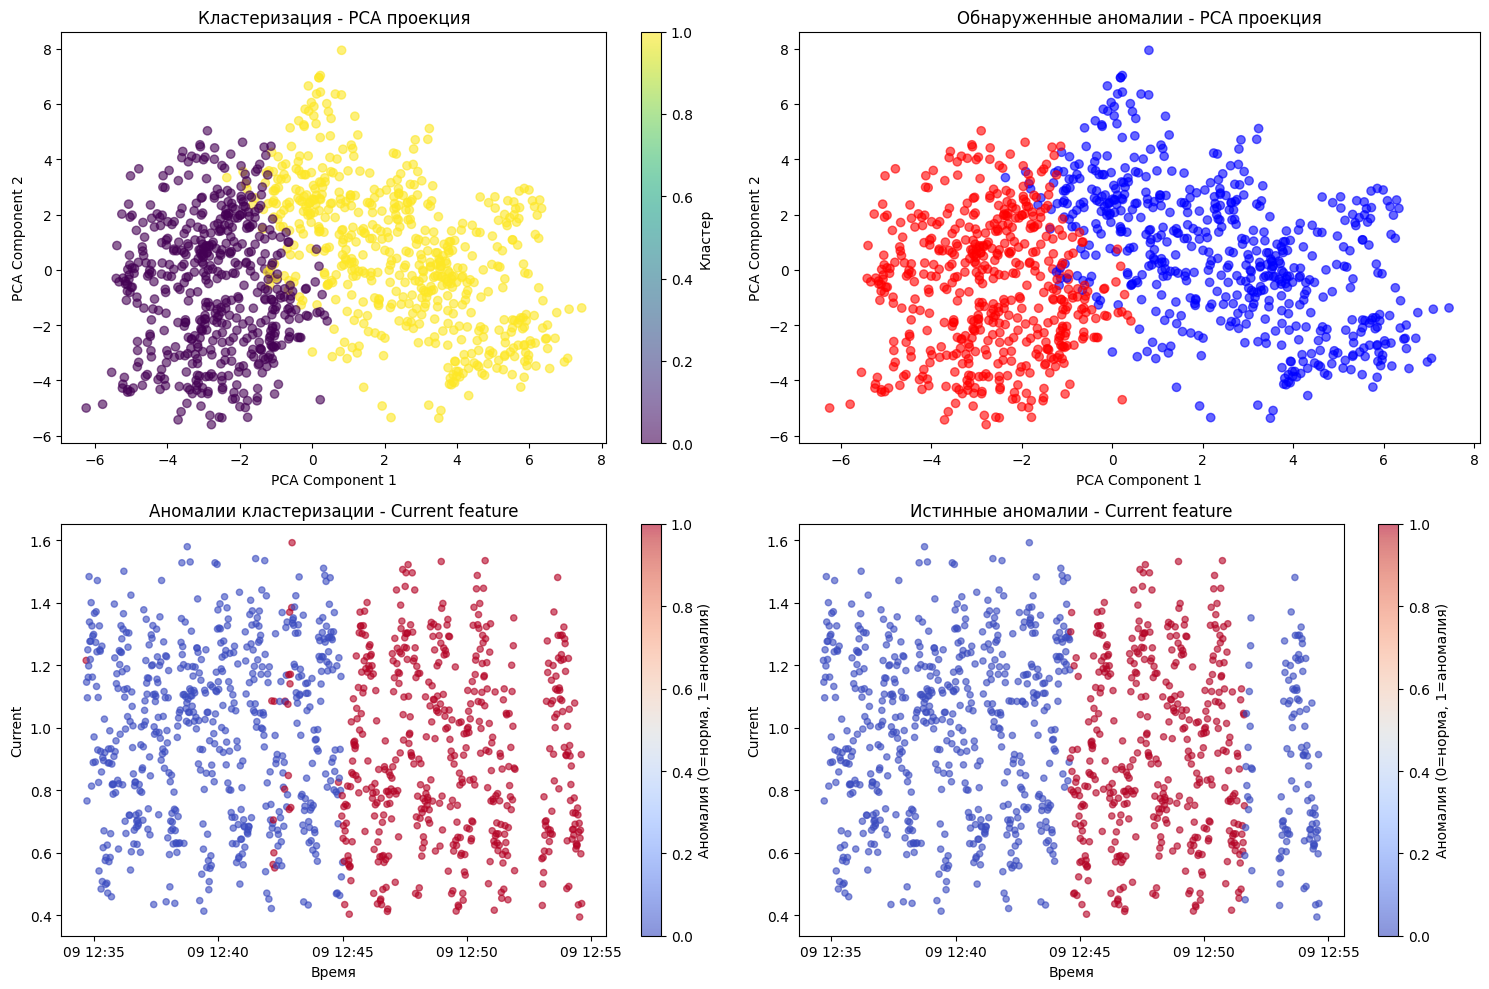

In [119]:
# Визуализация кластеризации
plt.figure(figsize=(15, 10))

# PCA проекция с кластерами
plt.subplot(2, 2, 1)
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1],
                     c=cluster_labels, cmap='viridis', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Кластеризация - PCA проекция')
plt.colorbar(scatter, label='Кластер')

# PCA проекция с аномалиями
plt.subplot(2, 2, 2)
colors = ['blue' if x == 0 else 'red' for x in anomalies_clustering]
plt.scatter(pca_result[:, 0], pca_result[:, 1],
           c=colors, alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Обнаруженные аномалии - PCA проекция')

# Временной ряд с аномалиями кластеризации
plt.subplot(2, 2, 3)
# Синхронизируем с исходными данными
common_index = df.index.intersection(anomalies_clustering_series.index)
plt.scatter(common_index, df.loc[common_index, 'Current'],
           c=anomalies_clustering_series.loc[common_index],
           cmap='coolwarm', alpha=0.6, s=20)
plt.title('Аномалии кластеризации - Current feature')
plt.xlabel('Время')
plt.ylabel('Current')
plt.colorbar(label='Аномалия (0=норма, 1=аномалия)')

# Сравнение с истинными аномалиями
plt.subplot(2, 2, 4)
true_anomalies_common = df.loc[common_index, 'anomaly']
plt.scatter(common_index, df.loc[common_index, 'Current'],
           c=true_anomalies_common,
           cmap='coolwarm', alpha=0.6, s=20)
plt.title('Истинные аномалии - Current feature')
plt.xlabel('Время')
plt.ylabel('Current')
plt.colorbar(label='Аномалия (0=норма, 1=аномалия)')

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

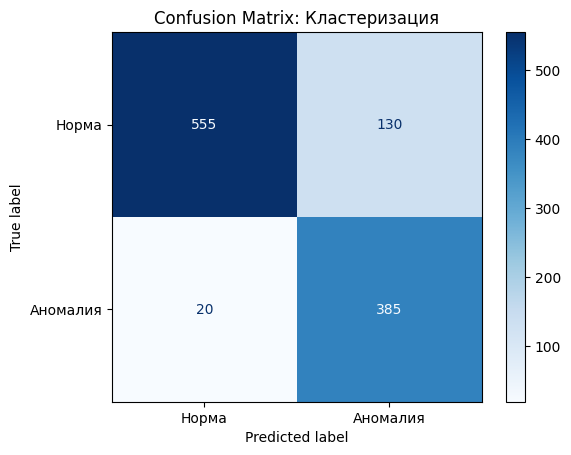

KMeans_2:
              precision    recall  f1-score   support

         0.0       0.63      0.90      0.74       689
         1.0       0.34      0.09      0.14       405

    accuracy                           0.60      1094
   macro avg       0.48      0.49      0.44      1094
weighted avg       0.52      0.60      0.52      1094

\KMeans_3:
              precision    recall  f1-score   support

         0.0       0.63      1.00      0.77       689
         1.0       0.50      0.00      0.00       405

    accuracy                           0.63      1094
   macro avg       0.57      0.50      0.39      1094
weighted avg       0.58      0.63      0.49      1094



In [158]:
# Матрица ошибок для кластеризации
plt.figure(figsize=(8, 6))
cm_clustering = confusion_matrix(true_anomalies_common,
                                anomalies_clustering_series.loc[common_index])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_clustering,
                            display_labels=['Норма', 'Аномалия'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Кластеризация')
plt.show()

print("KMeans_2:")
print(classification_report(df['anomaly'], anomalies_iqr_1_5))

print("\KMeans_3:")
print(classification_report(df['anomaly'], anomalies_iqr_3))

In [160]:
# Оценка качества методов кластеризации
results['KMeans_2'] = classification_report(df['anomaly'], anomalies_iqr_1_5)
results['KMeans_3'] =classification_report(df['anomaly'], anomalies_iqr_3)

Isolation Forest

In [124]:
# Подготовка данных
X_iso = df[numerical_features].copy()

In [125]:
# Масштабирование
scaler_iso = StandardScaler()
X_scaled_iso = scaler_iso.fit_transform(X_iso)

In [126]:
# Обучение
iso_forest = IsolationForest(contamination=0.1, random_state=42, n_estimators=100)
anomalies_iso = iso_forest.fit_predict(X_scaled_iso)

In [127]:
# Преобразование меток: возвращает 1 для нормальных, -1 для аномальных
anomalies_iso = (anomalies_iso == -1).astype(int)

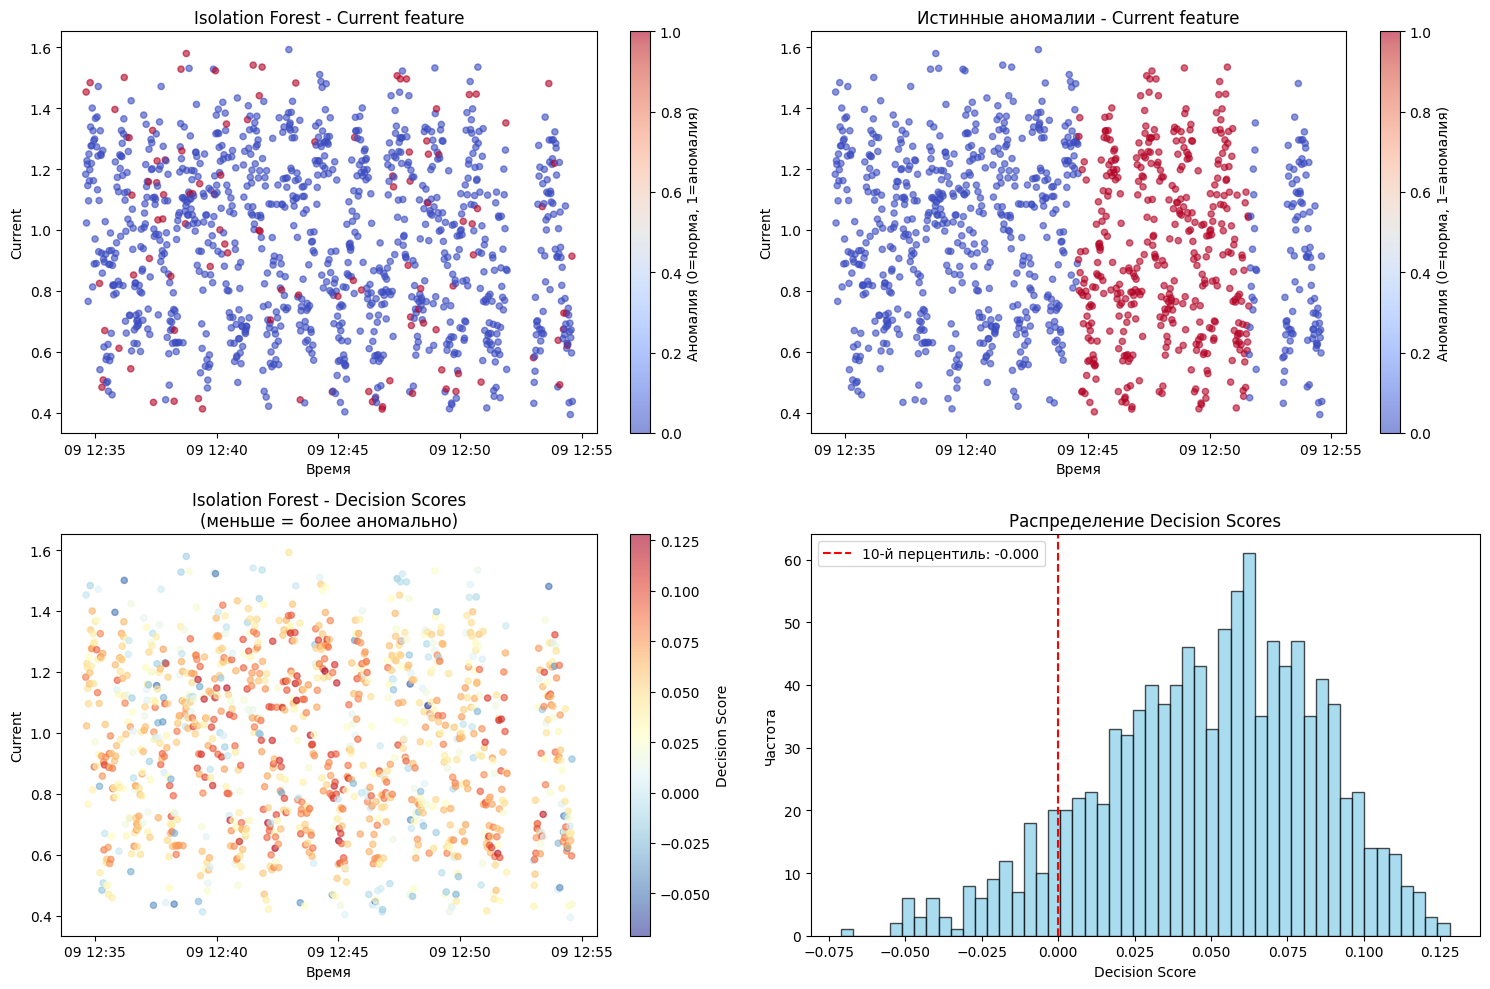

In [128]:
# Визуализация результатов Isolation Forest
plt.figure(figsize=(15, 10))

# Isolation Forest аномалии
plt.subplot(2, 2, 1)
plt.scatter(df.index, df['Current'],
           c=anomalies_iso, cmap='coolwarm', alpha=0.6, s=20)
plt.title('Isolation Forest - Current feature')
plt.xlabel('Время')
plt.ylabel('Current')
plt.colorbar(label='Аномалия (0=норма, 1=аномалия)')

# Сравнение с истинными аномалиями
plt.subplot(2, 2, 2)
plt.scatter(df.index, df['Current'],
           c=df['anomaly'], cmap='coolwarm', alpha=0.6, s=20)
plt.title('Истинные аномалии - Current feature')
plt.xlabel('Время')
plt.ylabel('Current')
plt.colorbar(label='Аномалия (0=норма, 1=аномалия)')

# Decision function (уверенность модели)
plt.subplot(2, 2, 3)
decision_scores = iso_forest.decision_function(X_scaled_iso)
plt.scatter(df.index, df['Current'],
           c=decision_scores, cmap='RdYlBu_r', alpha=0.6, s=20)
plt.title('Isolation Forest - Decision Scores\n(меньше = более аномально)')
plt.xlabel('Время')
plt.ylabel('Current')
plt.colorbar(label='Decision Score')

# Распределение decision scores
plt.subplot(2, 2, 4)
plt.hist(decision_scores, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(x=np.percentile(decision_scores, 10), color='red', linestyle='--',
           label=f'10-й перцентиль: {np.percentile(decision_scores, 10):.3f}')
plt.xlabel('Decision Score')
plt.ylabel('Частота')
plt.title('Распределение Decision Scores')
plt.legend()

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

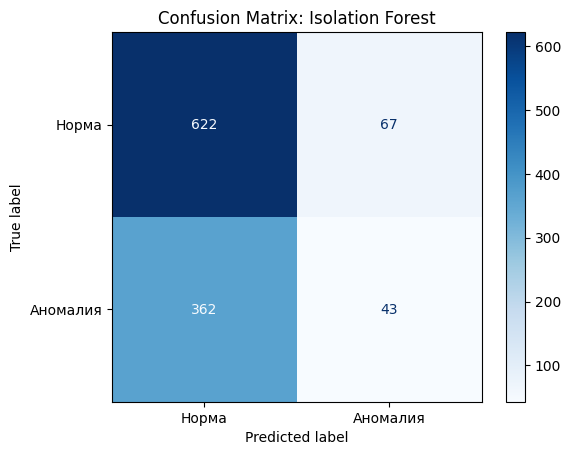

              precision    recall  f1-score   support

         0.0       0.63      0.90      0.74       689
         1.0       0.39      0.11      0.17       405

    accuracy                           0.61      1094
   macro avg       0.51      0.50      0.46      1094
weighted avg       0.54      0.61      0.53      1094



In [129]:
# Матрица ошибок для Isolation Forest
plt.figure(figsize=(8, 6))
cm_iso = confusion_matrix(df['anomaly'], anomalies_iso)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_iso,
                            display_labels=['Норма', 'Аномалия'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Isolation Forest')
plt.show()

print(classification_report(df['anomaly'], anomalies_iso))

In [157]:
results['Isolation Forest'] = (classification_report(df['anomaly'], anomalies_iso))

Сравнительный анализ

In [192]:
# Создаем расширенную сводную таблицу результатов
def calculate_detailed_metrics(y_true, y_pred, method_name):
    """
    Расчет расширенных метрик для сравнения методов
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Основные метрики
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    # Дополнительные метрики
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

    return {
        'method': method_name,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy,
        'specificity': specificity,
        'false_positive_rate': false_positive_rate,
        'false_negative_rate': false_negative_rate
    }


In [193]:
# Собираем результаты всех методов
results = {}

# 1. IQR 1.5
results['IQR_1.5'] = calculate_detailed_metrics(df['anomaly'], anomalies_iqr_1_5, 'IQR_1.5')

# 2. IQR 3
results['IQR_3'] = calculate_detailed_metrics(df['anomaly'], anomalies_iqr_3, 'IQR_3')

# 3. Кластеризация (синхронизируем индексы)
y_true_clustering = df.loc[common_index, 'anomaly']
y_pred_clustering = anomalies_clustering_series.loc[common_index]
results['Clustering'] = calculate_detailed_metrics(y_true_clustering, y_pred_clustering, 'Clustering')

# 4. Isolation Forest
results['Isolation_Forest'] = calculate_detailed_metrics(df['anomaly'], anomalies_iso, 'Isolation_Forest')


In [196]:
# Создаем DataFrame результатов
results_df = pd.DataFrame(results).T

# Добавляем дополнительные метрики
results_df['detected_anomalies'] = results_df['tp'] + results_df['fp']
results_df['true_anomalies'] = [df['anomaly'].sum()] * len(results_df)  # Общее количество истинных аномалий
results_df['detection_ratio'] = results_df['detected_anomalies'] / results_df['true_anomalies']
results_df['true_positive_ratio'] = results_df['tp'] / results_df['true_anomalies']

# Для кластеризации корректируем true_anomalies (только для общего индекса)
results_df.loc['Clustering', 'true_anomalies'] = y_true_clustering.sum()

In [197]:
# Сортируем по F1-score
results_df = results_df.sort_values('f1', ascending=False).round(4)

print("Расширенная сводная таблица результатов:")
print("="*100)
print(results_df[['precision', 'recall', 'f1', 'accuracy', 'specificity',
                 'tp', 'fp', 'fn', 'tn', 'detected_anomalies', 'detection_ratio']])

Расширенная сводная таблица результатов:
                 precision    recall        f1  accuracy specificity   tp  \
Clustering        0.747573  0.950617  0.836957  0.862385    0.810219  385   
Isolation_Forest  0.390909  0.106173   0.16699  0.607861    0.902758   43   
IQR_1.5           0.342857  0.088889  0.141176  0.599634    0.899855   36   
IQR_3                  0.5  0.002469  0.004914  0.629799    0.998549    1   

                   fp   fn   tn detected_anomalies detection_ratio  
Clustering        130   20  555                515        1.271605  
Isolation_Forest   67  362  622                110        0.271605  
IQR_1.5            69  369  620                105        0.259259  
IQR_3               1  404  688                  2        0.004938  


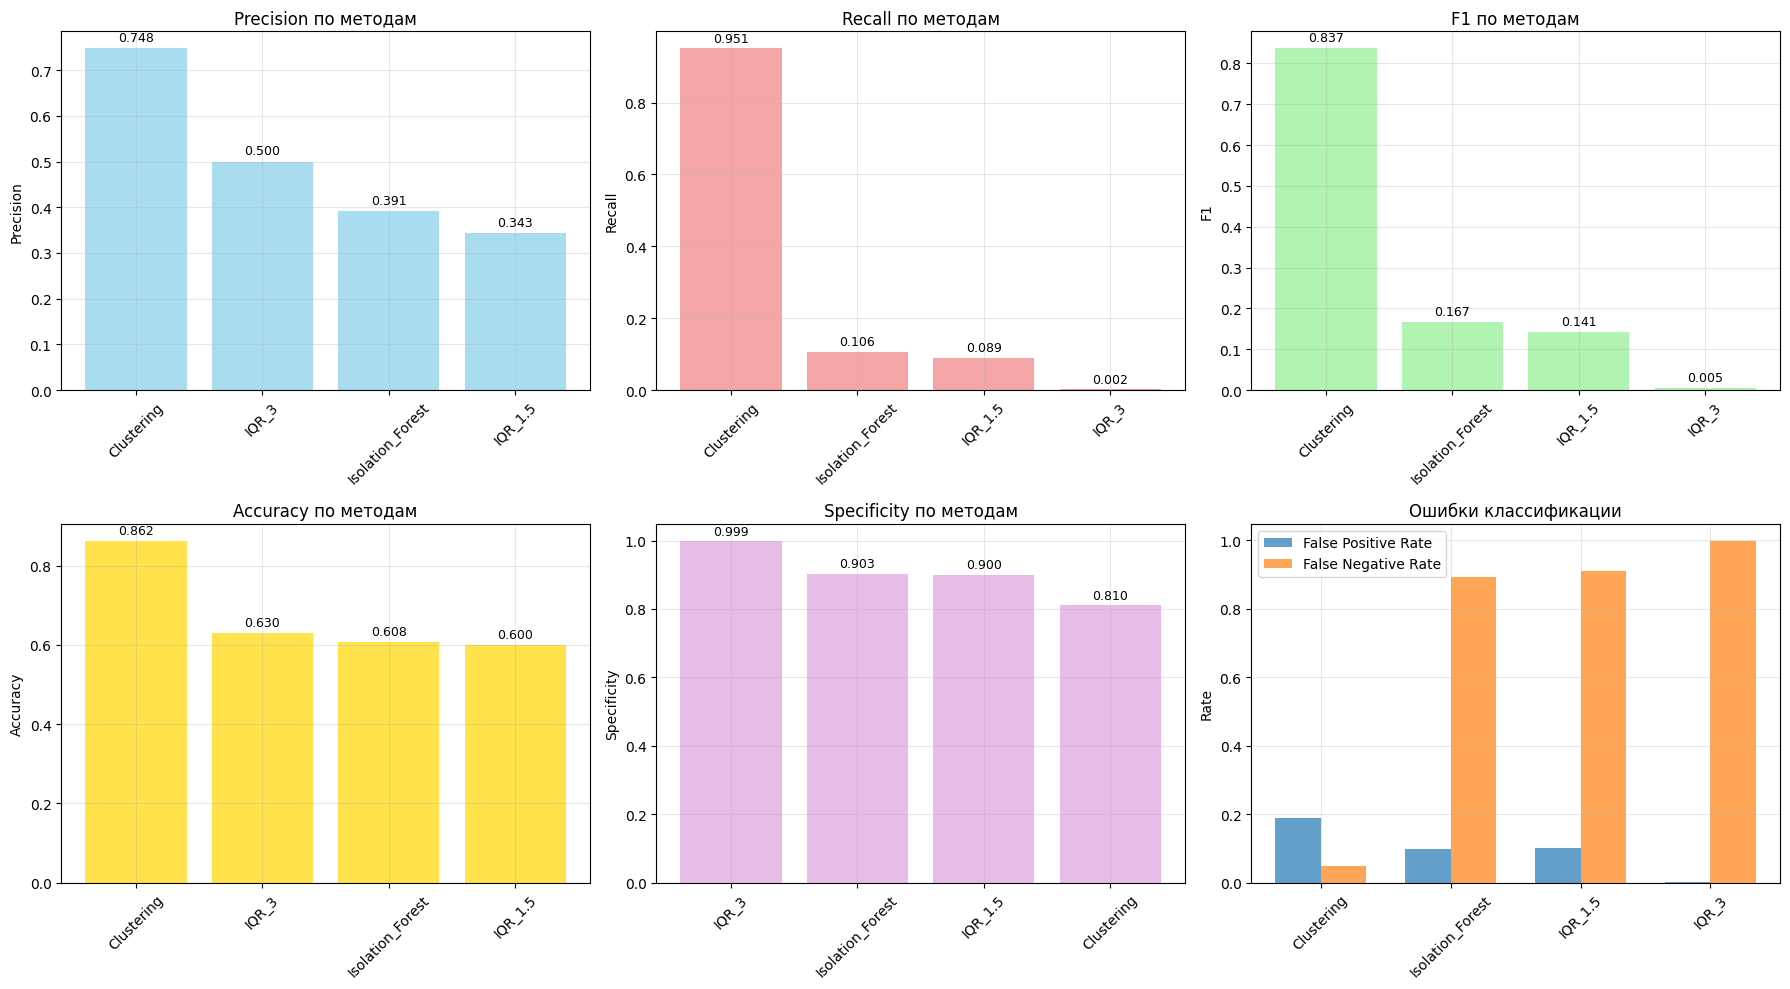

In [200]:
# Визуализация сравнения метрик
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Основные метрики
metrics_main = ['precision', 'recall', 'f1', 'accuracy', 'specificity']
colors_main = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum']

for i, (metric, color) in enumerate(zip(metrics_main, colors_main)):
    ax = axes[i//3, i%3]
    results_df_sorted = results_df.sort_values(metric, ascending=False)
    bars = ax.bar(results_df_sorted.index, results_df_sorted[metric], color=color, alpha=0.7)
    ax.set_title(f'{metric.capitalize()} по методам')
    ax.set_ylabel(metric.capitalize())
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

    # Добавляем значения на столбцы
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Матрица ошибок визуализация
ax = axes[1, 2]
error_rates = results_df[['false_positive_rate', 'false_negative_rate']]
x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, error_rates['false_positive_rate'], width,
               label='False Positive Rate', alpha=0.7)
bars2 = ax.bar(x + width/2, error_rates['false_negative_rate'], width,
               label='False Negative Rate', alpha=0.7)

ax.set_title('Ошибки классификации')
ax.set_ylabel('Rate')
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()